In [1]:
from sklearn.datasets import  fetch_openml
import pandas as pd
### Import Packages ###

import os
import math as math
import pandas as pd
import random as random

### Append Path ###
import sys
sys.path.append('..')

### Local Packages ###
from utils.Prediction import *
from utils.Selector import *
from utils.Auxiliary import *
from utils.Main import *

In [6]:
import os
import pandas as pd

base_dir = r"C:\vscode\RashomonActiveLearning-1\Code\Notebooks\dataset_files"

pickle_paths = {
    "BostonHousing":      os.path.join(base_dir, "BostonHousing.pkl"),
    "YachtHydrodynamics": os.path.join(base_dir, "YachtHydrodynamics.pkl"),
    "AutoMPG":            os.path.join(base_dir, "AutoMPG.pkl"),
    "ConcreteStrength":   os.path.join(base_dir, "ConcreteStrength.pkl"),
    "WineQualityRed":     os.path.join(base_dir, "WineQualityRed.pkl"),
    "WineQualityWhite":   os.path.join(base_dir, "WineQualityWhite.pkl"),
    "ConcreteSlumpTest":  os.path.join(base_dir, "ConcreteSlumpTest.pkl"),
    # newly added:
    "WageData":           os.path.join(base_dir, "WageData.pkl"),
    "YachtHydro":         os.path.join(base_dir, "YachtHydro.pkl"),
    "ThirdData":          os.path.join(base_dir, "ThirdData.pkl"),
}

def drop_non_numeric_columns(df, label_col="Y"):
    features = df.drop(columns=[label_col], errors="ignore")
    labels   = df[label_col] if label_col in df.columns else None
    num_feats = features.select_dtypes(include="number").copy()
    if labels is not None:
        num_feats[label_col] = labels
    return num_feats

def load_and_prep(name, path):
    # 1) read the raw pickle
    df = pd.read_pickle(path)

    # 2) rename the target → "Y"
    rename_map = {
        "BostonHousing":      {"target": "Y"},
        "YachtHydrodynamics": {"ResResistPerWtDisp": "Y"},
        "AutoMPG":            {"mpg": "Y"},
        "ConcreteStrength":   {"compressive_strength": "Y"},
        "WineQualityRed":     {"quality": "Y"},
        "WineQualityWhite":   {"quality": "Y"},
        "ConcreteSlumpTest":  {"slump": "Y"},
        "WageData":           {"WAGE": "Y"},               # explicitly rename WAGE→Y
        "YachtHydro":         {"ResResistPerWtDisp": "Y"}, # same as original
        # ThirdData: falls through to generic branch below
    }

    if name in rename_map:
        df = df.rename(columns=rename_map[name])
    else:
        # if we don't know the target name, assume it's the last column
        df = df.rename(columns={df.columns[-1]: "Y"})

    # 2.1) drop any known junk columns
    if name == "AutoMPG":
        df = df.drop(columns=["car_name"], errors="ignore")

    # 3) coerce ALL columns to numeric (strings → NaN)
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # 4) drop any columns still non-numeric & reattach Y
    df = drop_non_numeric_columns(df, label_col="Y")

    # 5) drop rows with any missing values
    df = df.dropna()

    # 6) reset index so splits work smoothly
    df = df.reset_index(drop=True)

    # 7) cast index to float for any float‐based .loc indexing
    df.index = df.index.astype(float)

    return df

# build your datasets dict
datasets = {
    name: load_and_prep(name, path)
    for name, path in pickle_paths.items()
}

# sanity‐check
for n, df in datasets.items():
    print(n, "→", df.shape)
    print(df.head(), "\n")


BostonHousing → (506, 16)
     CRIM_1  CRIM_2  CRIM_3  NOX_1  NOX_2  NOX_3  RM_1  RM_2  RM_3  PTRATIO_1  \
0.0     1.0     0.0     0.0    0.0    1.0    0.0   0.0   0.0   1.0        1.0   
1.0     1.0     0.0     0.0    1.0    0.0    0.0   0.0   1.0   0.0        1.0   
2.0     1.0     0.0     0.0    1.0    0.0    0.0   0.0   0.0   1.0        1.0   
3.0     1.0     0.0     0.0    1.0    0.0    0.0   0.0   0.0   1.0        0.0   
4.0     1.0     0.0     0.0    1.0    0.0    0.0   0.0   0.0   1.0        0.0   

     PTRATIO_2  PTRATIO_3  LSTAT_1  LSTAT_2  LSTAT_3      Y  
0.0        0.0        0.0      1.0      0.0      0.0  False  
1.0        0.0        0.0      0.0      1.0      0.0  False  
2.0        0.0        0.0      1.0      0.0      0.0   True  
3.0        1.0        0.0      1.0      0.0      0.0   True  
4.0        1.0        0.0      1.0      0.0      0.0   True   

YachtHydrodynamics → (308, 7)
     LongPos_CenterFlotation  PrismaticCoeff  LengthDispRatio  \
0.0               

In [7]:
import os

# 1) Where to write them
out_dir = r"C:\vscode\RashomonActiveLearning-1\Code\Notebooks\dataset_files"
os.makedirs(out_dir, exist_ok=True)

# 2) Dump each processed df (with Y) back to disk under the EXACT name your experiments expect
for name, df in datasets.items():
    out_path = os.path.join(out_dir, f"{name}.pkl")
    df.to_pickle(out_path)
    print(f"✅  Wrote processed {name} → {out_path}")


✅  Wrote processed BostonHousing → C:\vscode\RashomonActiveLearning-1\Code\Notebooks\dataset_files\BostonHousing.pkl
✅  Wrote processed YachtHydrodynamics → C:\vscode\RashomonActiveLearning-1\Code\Notebooks\dataset_files\YachtHydrodynamics.pkl
✅  Wrote processed AutoMPG → C:\vscode\RashomonActiveLearning-1\Code\Notebooks\dataset_files\AutoMPG.pkl
✅  Wrote processed ConcreteStrength → C:\vscode\RashomonActiveLearning-1\Code\Notebooks\dataset_files\ConcreteStrength.pkl
✅  Wrote processed WineQualityRed → C:\vscode\RashomonActiveLearning-1\Code\Notebooks\dataset_files\WineQualityRed.pkl
✅  Wrote processed WineQualityWhite → C:\vscode\RashomonActiveLearning-1\Code\Notebooks\dataset_files\WineQualityWhite.pkl
✅  Wrote processed ConcreteSlumpTest → C:\vscode\RashomonActiveLearning-1\Code\Notebooks\dataset_files\ConcreteSlumpTest.pkl
✅  Wrote processed WageData → C:\vscode\RashomonActiveLearning-1\Code\Notebooks\dataset_files\WageData.pkl
✅  Wrote processed YachtHydro → C:\vscode\RashomonActi

In [8]:
from sklearn.datasets import  fetch_openml
import pandas as pd
### Import Packages ###

import os
import math as math
import pandas as pd
import random as random

### Append Path ###
import sys
sys.path.append('..')

### Local Packages ###
from utils.Prediction import *
from utils.Selector import *
from utils.Auxiliary import *
from utils.Main import *

# boston = fetch_openml(name="boston", version=1, as_frame=True)
# df_boston = pd.DataFrame(boston.data, columns=boston.feature_names)
# df_boston['target'] = boston.target

# datasets = {
#     #"Diabetes": df_diabetes,
#     # "CaliforniaHousing": df_california,
#      "BostonHousing": df_boston,
#     # "AmesHousing": df_ames,
# }

# def drop_non_numeric_columns(df, label_col="Y"):
#     """Drops all non-numeric columns (except your label col, if you want to keep it)."""
#     # Separate the label from the features
#     features_df = df.loc[:, df.columns != label_col]
#     label_series = df[label_col] if label_col in df.columns else None

#     # Keep only numeric columns
#     numeric_features_df = features_df.select_dtypes(include=["number"]).copy()

#     # Reattach the label if present
#     if label_series is not None:
#         numeric_features_df[label_col] = label_series
    
#     return numeric_features_df

# # Example usage:
# for dataset_name, df in datasets.items():
#     datasets[dataset_name] = drop_non_numeric_columns(df, label_col="Y")


# for key, df in datasets.items():
#     if "target" in df.columns:
#         df.rename(columns={"target": "Y"}, inplace=True)
# import os

# 2. Define your model and selector lists
model_types = [
    "LinearRegressionFunction",
    # "RidgeRegressionFunction",
    #"RandomForestRegressorFunction",
    #"XGBoostRegressorFunction",
    #"NeuralNetworkFunction"
]


selector_types = [
    "PassiveLearning",
    #"GSxFunction",            
    # "GSxFunctionAverage",      
    #"GSyFunction",              
    # "GSyFunctionAverage",     
    #"iGSFunction",             
    # "iGSFunctionAverage",     
    #"iGSFunctionStandardized", 
    #"iGSFunctionAverageStandardized",
    #"WiGSFunction_linear",
    #"WiGSFunction_exponential",
    #"WiGSFunction_adaptive"
]

#for ridge regression use 0.01 alpha

# Import or define your OneIterationFunction and TrainTestCandidateSplit functions
from utils.Main import OneIterationFunction, TrainTestCandidateSplit
 
all_results = run_active_learning_experiments(
    datasets=datasets,
    model_types=model_types,
    selector_types=selector_types,
    OneIterationFunction=OneIterationFunction,
    TrainTestCandidateSplit=TrainTestCandidateSplit,
    n_simulations=1,          # Use 1 for a quick run; set 100+ for full experiments
    test_proportion=0.2,
    candidate_proportion=0.8,
    plot=True,
    do_wilcoxon=False,
    round_wilcoxon=4,
    output_dir="results"
)



=== DATASET: BostonHousing | MODEL: LinearRegressionFunction ===
Iteration: 0
Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
Iteration: 21
Iteration: 22
Iteration: 23
Iteration: 24
Iteration: 25
Iteration: 26
Iteration: 27
Iteration: 28
Iteration: 29
Iteration: 30
Iteration: 31
Iteration: 32
Iteration: 33
Iteration: 34
Iteration: 35
Iteration: 36
Iteration: 37
Iteration: 38
Iteration: 39
Iteration: 40
Iteration: 41
Iteration: 42
Iteration: 43
Iteration: 44
Iteration: 45
Iteration: 46
Iteration: 47
Iteration: 48
Iteration: 49
Iteration: 50
Iteration: 51
Iteration: 52
Iteration: 53
Iteration: 54
Iteration: 55
Iteration: 56
Iteration: 57
Iteration: 58
Iteration: 59
Iteration: 60
Iteration: 61
Iteration: 62
Iteration: 63
Iteration: 64
Iteration: 65
Iteration: 66
Iterat

In [1]:
#DONT RUN UNLESS YOU WANT TO SAVE THE RESULTS TO THE FILE LISTED
#WILL OVERWRITE THE FILE

import pickle
# make sure the folder exists
import os
os.makedirs("results", exist_ok=True)
import os
print(os.path.isdir("results"))

# Save to disk
with open("results/*****ENTER NAME *****.pkl", "wb") as f:
    pickle.dump(all_results, f)
print("all_results saved to results/*****ENTER NAME *****.pkl")

True


NameError: name 'all_results' is not defined

In [2]:
import pickle
with open("results/all_results.pkl", "rb") as f:
    all_results = pickle.load(f)
print("Reloaded all_results; keys:", list(all_results.keys())[:5], "…")

EOFError: Ran out of input

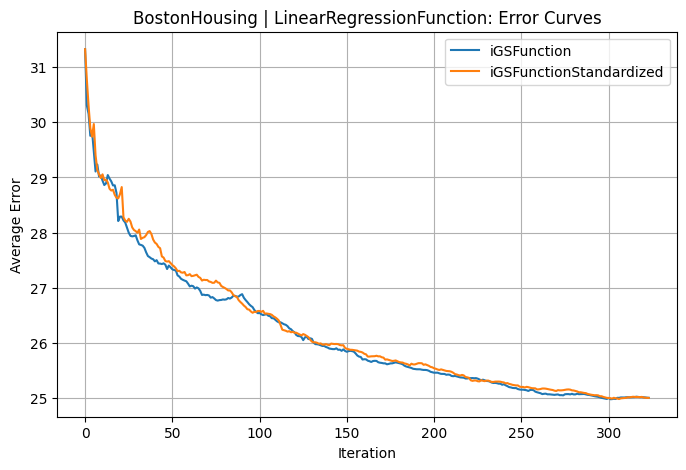

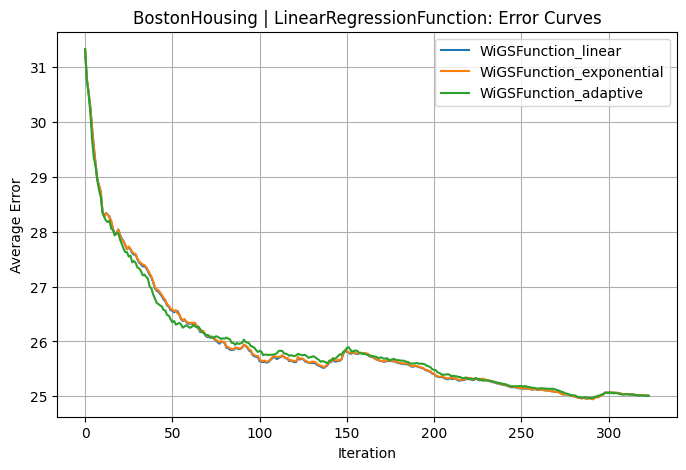

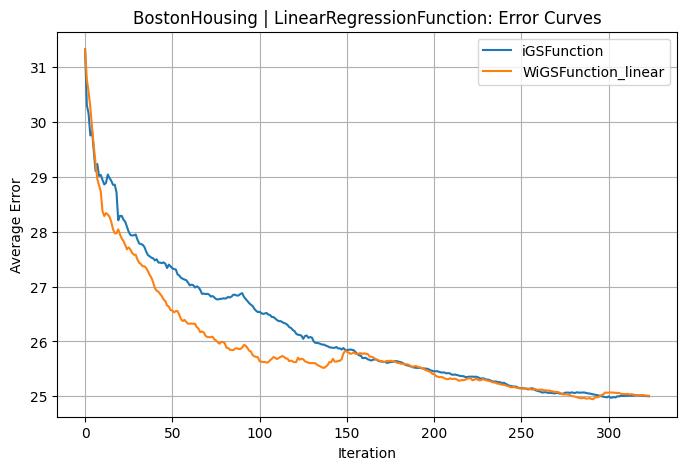

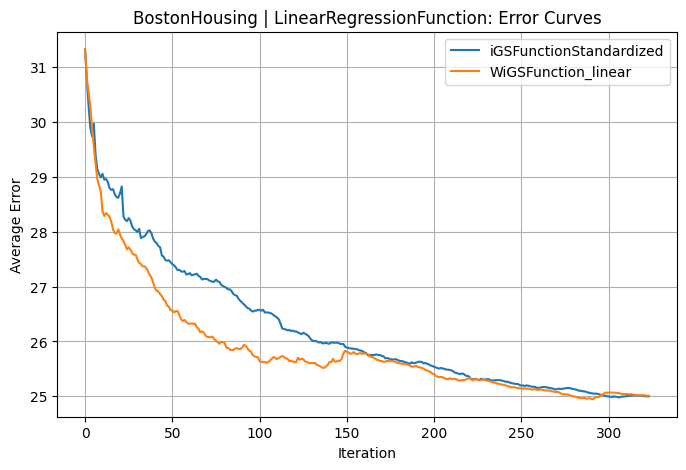

In [4]:
import matplotlib.pyplot as plt

def plot_custom_error_curves(results_summary, dataset_name, model_name, selectors=None):
    """
    Plot custom error curves for specified selectors from the results_summary.

    Parameters
    ----------
    results_summary : dict
        Output of run_active_learning_experiments.
    dataset_name : str
        Name of the dataset (key[0] in results_summary).
    model_name : str
        Name of the model (key[1] in results_summary).
    selectors : list of str, optional
        Specific selector names to plot. If None, plots all selectors for that dataset+model.
    """
    # collect keys matching dataset and model
    keys = [key for key in results_summary
            if key[0] == dataset_name and key[1] == model_name]
    available = [key[2] for key in keys]
    to_plot = selectors or available

    plt.figure(figsize=(8, 5))
    for sel in to_plot:
        if (dataset_name, model_name, sel) in results_summary:
            info = results_summary[(dataset_name, model_name, sel)]
            plt.plot(info["avg_error"], label=sel)
        else:
            print(f"Selector '{sel}' not found for {dataset_name} + {model_name}")
    plt.xlabel("Iteration")
    plt.ylabel("Average Error")
    plt.title(f"{dataset_name} | {model_name}: Error Curves")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_custom_error_curves(
    all_results,
    "BostonHousing",
    "LinearRegressionFunction",
    selectors=["iGSFunction", "iGSFunctionStandardized"]
)

plot_custom_error_curves(
    all_results,
    "BostonHousing",
    "LinearRegressionFunction",
    selectors=["WiGSFunction_linear", "WiGSFunction_exponential", "WiGSFunction_adaptive"]
)
plot_custom_error_curves(
    all_results,
    "BostonHousing",
    "LinearRegressionFunction",
    selectors=["iGSFunction", "WiGSFunction_linear"]
)

plot_custom_error_curves(
    all_results,
    "BostonHousing",
    "LinearRegressionFunction",
    selectors=["iGSFunctionStandardized", "WiGSFunction_linear"]
)



In [5]:
import pandas as pd

# 1) Yacht Hydrodynamics
yacht_cols = [
    "LongPos_CenterFlotation",
    "PrismaticCoeff",
    "LengthDispRatio",
    "BeamDraughtRatio",
    "LengthBeamRatio",
    "FroudeNum",
    "ResResistPerWtDisp"
]
df_yacht = pd.read_csv(
    r"C:\Users\truss\Downloads\yacht+hydrodynamics\yacht_hydrodynamics.data",
    header=None,
    delim_whitespace=True,
    names=yacht_cols
)
df_yacht.to_pickle("yacht_hydrodynamics.pkl")


# 2) Auto MPG
import pandas as pd

auto_cols = [
    "mpg","cylinders","displacement","horsepower",
    "weight","acceleration","model_year","origin","car_name"
]

records = []
with open(r"C:\Users\truss\Downloads\auto+mpg\auto-mpg.data", "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        # 1) carve out the car_name inside quotes
        if '"' in line:
            pre, rest = line.split('"', 1)
            name, _ = rest.split('"',1)
        else:
            pre = line
            name = ""
        # 2) split the numeric part
        nums = pre.split()
        if len(nums) != 8:
            raise ValueError(f"Expected 8 numeric fields, got {len(nums)} on line:\n {line}")
        records.append(nums + [name])

df_auto = pd.DataFrame(records, columns=auto_cols)

# 3) coerce numeric columns, turning '?' → NaN
for c in auto_cols[:-1]:
    df_auto[c] = pd.to_numeric(df_auto[c], errors="coerce")

# 4) now you can save it as before
df_auto.to_pickle("auto_mpg.pkl")

print(df_auto.head())



# 3) Concrete Compressive Strength
concrete_cols = [
    "cement","slag","fly_ash","water",
    "superplasticizer","coarse_agg","fine_agg",
    "age","compressive_strength"
]
df_conc = pd.read_excel(
    r"C:\Users\truss\Downloads\concrete+compressive+strength\Concrete_Data.xls",
    header=None,
    names=concrete_cols
)
df_conc.to_pickle("concrete_compressive_strength.pkl")


# 4) Wine Quality — Red
df_wine_red = pd.read_csv(
    r"C:\Users\truss\Downloads\wine+quality\winequality-red.csv",
    sep=";",
    header=0
)
df_wine_red.to_pickle("winequality_red.pkl")


# 5) Wine Quality — White
df_wine_white = pd.read_csv(
    r"C:\Users\truss\Downloads\wine+quality\winequality-white.csv",
    sep=";",
    header=0
)
df_wine_white.to_pickle("winequality_white.pkl")


# 6) Concrete Slump Test
slump_cols = [
    "cement","slag","fly_ash","water",
    "superplasticizer","coarse_agg","fine_agg",
    "slump","flow","compressive_strength"
]
df_slump = pd.read_csv(
    r"C:\Users\truss\Downloads\concrete+slump+test\slump_test.data",
    header=None,
    delim_whitespace=True,
    names=slump_cols
)
df_slump.to_pickle("concrete_slump_test.pkl")


C:\Users\truss\AppData\Local\Temp\ipykernel_78688\3751429769.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_yacht = pd.read_csv(


    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0       150.0  3433.0          12.0   
4  17.0          8         302.0       140.0  3449.0          10.5   

   model_year  origin                   car_name  
0          70       1  chevrolet chevelle malibu  
1          70       1          buick skylark 320  
2          70       1         plymouth satellite  
3          70       1              amc rebel sst  
4          70       1                ford torino  


C:\Users\truss\AppData\Local\Temp\ipykernel_78688\3751429769.py:100: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_slump = pd.read_csv(


In [6]:
import os, glob

# 1. What folder are we in?
cwd = os.getcwd()
print("Current working directory:", cwd)

# 2. Find all .pkl files here
pkls = glob.glob(os.path.join(cwd, "*.pkl"))
if not pkls:
    print("No .pkl files found in", cwd)
else:
    print("Found .pkl files:")
    for p in pkls:
        print("  ", os.path.abspath(p))

import os
import glob
import shutil

# Source directory (where your .pkl files currently are)
src_dir = os.getcwd()  

# Destination directory
dst_dir = r"C:\vscode\RashomonActiveLearning-1\Code\Notebooks\dataset_files"

# Create destination if it doesn't exist
os.makedirs(dst_dir, exist_ok=True)

# Move every .pkl
for pkl_file in glob.glob(os.path.join(src_dir, "*.pkl")):
    dest_path = os.path.join(dst_dir, os.path.basename(pkl_file))
    print(f"Moving {pkl_file} → {dest_path}")
    shutil.move(pkl_file, dest_path)



Current working directory: c:\vscode\RashomonActiveLearning-1\Code\Notebooks
Found .pkl files:
   c:\vscode\RashomonActiveLearning-1\Code\Notebooks\auto_mpg.pkl
   c:\vscode\RashomonActiveLearning-1\Code\Notebooks\concrete_compressive_strength.pkl
   c:\vscode\RashomonActiveLearning-1\Code\Notebooks\concrete_slump_test.pkl
   c:\vscode\RashomonActiveLearning-1\Code\Notebooks\winequality_red.pkl
   c:\vscode\RashomonActiveLearning-1\Code\Notebooks\winequality_white.pkl
   c:\vscode\RashomonActiveLearning-1\Code\Notebooks\yacht_hydrodynamics.pkl
Moving c:\vscode\RashomonActiveLearning-1\Code\Notebooks\auto_mpg.pkl → C:\vscode\RashomonActiveLearning-1\Code\Notebooks\dataset_files\auto_mpg.pkl
Moving c:\vscode\RashomonActiveLearning-1\Code\Notebooks\concrete_compressive_strength.pkl → C:\vscode\RashomonActiveLearning-1\Code\Notebooks\dataset_files\concrete_compressive_strength.pkl
Moving c:\vscode\RashomonActiveLearning-1\Code\Notebooks\concrete_slump_test.pkl → C:\vscode\RashomonActiveLea

In [9]:
import os, shutil

# where your underscored pickles currently live:
src_dir = r"C:\vscode\RashomonActiveLearning-1\Data\processed"

# where your experiment code is looking:
dst_dir = r"C:\vscode\RashomonActiveLearning-1\Code\Notebooks\dataset_files"
os.makedirs(dst_dir, exist_ok=True)

# map from the dataset‐names your code uses to the underscored filenames you have
name_map = {
    "BostonHousing":      "BostonHousing.pkl",              # you already have this one?
    "YachtHydrodynamics": "yacht_hydrodynamics.pkl",
    "AutoMPG":            "auto_mpg.pkl",
    "ConcreteStrength":   "concrete_compressive_strength.pkl",
    "WineQualityRed":     "winequality_red.pkl",
    "WineQualityWhite":   "winequality_white.pkl",
    "ConcreteSlumpTest":  "concrete_slump_test.pkl",
}

for ds_name, underscored in name_map.items():
    src = os.path.join(src_dir, underscored)
    dst = os.path.join(dst_dir, f"{ds_name}.pkl")
    print(f"Copying {src} → {dst}")
    shutil.copy(src, dst)


Copying C:\vscode\RashomonActiveLearning-1\Data\processed\BostonHousing.pkl → C:\vscode\RashomonActiveLearning-1\Code\Notebooks\dataset_files\BostonHousing.pkl
Copying C:\vscode\RashomonActiveLearning-1\Data\processed\yacht_hydrodynamics.pkl → C:\vscode\RashomonActiveLearning-1\Code\Notebooks\dataset_files\YachtHydrodynamics.pkl
Copying C:\vscode\RashomonActiveLearning-1\Data\processed\auto_mpg.pkl → C:\vscode\RashomonActiveLearning-1\Code\Notebooks\dataset_files\AutoMPG.pkl
Copying C:\vscode\RashomonActiveLearning-1\Data\processed\concrete_compressive_strength.pkl → C:\vscode\RashomonActiveLearning-1\Code\Notebooks\dataset_files\ConcreteStrength.pkl
Copying C:\vscode\RashomonActiveLearning-1\Data\processed\winequality_red.pkl → C:\vscode\RashomonActiveLearning-1\Code\Notebooks\dataset_files\WineQualityRed.pkl
Copying C:\vscode\RashomonActiveLearning-1\Data\processed\winequality_white.pkl → C:\vscode\RashomonActiveLearning-1\Code\Notebooks\dataset_files\WineQualityWhite.pkl
Copying C:\

In [17]:
import pandas as pd
import os

# 1) Define the column names exactly as the UCI docs say:
slump_cols = [
    "cement","slag","fly_ash","water",
    "superplasticizer","coarse_agg","fine_agg",
    "slump","flow","compressive_strength"
]

# 2) Read the CSV with commas
df_slump = pd.read_csv(
    r"C:\Users\truss\Downloads\concrete+slump+test\slump_test.data",
    header=None,
    names=slump_cols,
    sep=",",
    engine="python"
)

# 3) Rename the target → "Y"
df_slump = df_slump.rename(columns={"slump":"Y"})

# 4) (Optional) Check the shape & dtypes
print("Slump test shape:", df_slump.shape)
print(df_slump.dtypes)

# 5) Write out the new pickle into EXACTLY the spot your experiments will look
out_path = r"C:\vscode\RashomonActiveLearning-1\Code\Notebooks\dataset_files\ConcreteSlumpTest.pkl"
os.makedirs(os.path.dirname(out_path), exist_ok=True)
df_slump.to_pickle(out_path)
print("Wrote corrected slump pickle to:", out_path)


Slump test shape: (104, 10)
cement                  object
slag                    object
fly_ash                 object
water                   object
superplasticizer        object
coarse_agg              object
fine_agg                object
Y                       object
flow                    object
compressive_strength    object
dtype: object
Wrote corrected slump pickle to: C:\vscode\RashomonActiveLearning-1\Code\Notebooks\dataset_files\ConcreteSlumpTest.pkl


In [3]:
import os
import pandas as pd

processed_dir = r"C:\vscode\RashomonActiveLearning-1\Data\processed"
notebook_dir  = r"C:\vscode\RashomonActiveLearning-1\Code\Notebooks\dataset_files"

# map each dataset name → its .txt path and column list
datasets = {
    "WageData": {
        "txt":  os.path.join(processed_dir, "wage_data.txt.txt"),
        "cols": ["EDUCATION","SOUTH","SEX","EXPERIENCE","UNION","WAGE","AGE","RACE","OCCUPATION","SECTOR","MARR"]
    },
    "YachtHydro": {
        "txt":  os.path.join(processed_dir, "yacht_data.txt.txt"),
        # 7 inputs + 1 target
        "cols": ["LCB","Cp","L_D","B_T","L_B","F_n","ResistPerDisp","Y"]
    },
    "ThirdData": {
        "txt":  os.path.join(processed_dir, "third_data.txt.txt"),
        # 8 columns (all numeric)
        "cols": ["V1","V2","V3","V4","V5","V6","V7","V8"]
    }
}

for name, info in datasets.items():
    # 1) read the whitespace-delimited .txt
    df = pd.read_csv(info["txt"],
                     sep=r"\s+",
                     names=info["cols"],
                     engine="python")
    # 2) pickle into both places
    for out_dir in (processed_dir, notebook_dir):
        out_path = os.path.join(out_dir, f"{name}.pkl")
        df.to_pickle(out_path)
        print(f"✔ Saved {name} → {out_path}")


✔ Saved WageData → C:\vscode\RashomonActiveLearning-1\Data\processed\WageData.pkl
✔ Saved WageData → C:\vscode\RashomonActiveLearning-1\Code\Notebooks\dataset_files\WageData.pkl
✔ Saved YachtHydro → C:\vscode\RashomonActiveLearning-1\Data\processed\YachtHydro.pkl
✔ Saved YachtHydro → C:\vscode\RashomonActiveLearning-1\Code\Notebooks\dataset_files\YachtHydro.pkl
✔ Saved ThirdData → C:\vscode\RashomonActiveLearning-1\Data\processed\ThirdData.pkl
✔ Saved ThirdData → C:\vscode\RashomonActiveLearning-1\Code\Notebooks\dataset_files\ThirdData.pkl
